# The Effective-Tax-Rate Anomaly — a quantitative teardown 🔬
### ETR level & change · quintile sort · HAC *t* · label-shuffle placebo · rank-IC · window sign-flip · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the effective tax rate (income-tax expense / pretax income) from EDGAR 10-K facts, sort the cross-section, and test whether low-ETR firms out-earn (quality), under-earn (risk), or — as it turns out — neither.

> ⚠️ **Not investment advice.** Real data: EDGAR annual fundamentals + yfinance daily prices, 40 survivors, fiscal 2008-2024 (as-of 2026-06-30, ETR panel fp `74b7313496ca`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from effective_tax_rate import data, strategy as st

def load_real():
    """Cache-first real (etr, fwd) panels (empty frames offline)."""
    etr, fwd = data.load_panel()
    return etr, fwd

ETR, FWD = load_real()
HAVE_REAL = not ETR.empty and not FWD.empty
print("real ETR panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({ETR.shape[1]} names, fiscal {int(ETR.index.min())}-{int(ETR.index.max())})")


real ETR panel present: True (40 names, fiscal 2007-2026)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Low−high ETR hedge **-3.3%/yr** (HAC *t* **-0.91**, placebo *p* 0.422) — wrong sign, ≈ 0; rank-IC **-0.023** (*t* -0.46); ΔETR hedge **-2.3%/yr** (*t* -0.77); sign flips across windows. |
| **Tradability** | `MIRAGE` | Survivor basket, annual rebalance, high-ETR short leg. Gross -3.3%/yr → net -3.9%/yr (10 bps/leg × 0.64 turnover + 50 bps borrow). |

> 💡 In plain words: the engine works (the synthetic control proves it fires on a planted premium of *either* sign), but on this survivor basket the ETR sort carries no return information at all — a clean null.

## 1 · The claim, steelmanned

Let $E_i$ be firm $i$'s effective tax rate and $r_i$ its next-year return.

- **H₁ (quality / long-short).** $\mathbb{E}[r \mid \text{low ETR}] - \mathbb{E}[r \mid \text{high ETR}] > 0$ at *t* ≥ 2 (low-tax firms out-earn).
- **H₁′ (risk).** The *opposite* sign — low-ETR firms *under*-earn.
- **H₂ (firm-level).** A non-zero rank-IC between $E$ and $r$.
- **H₃ (change).** ΔETR (a shield reversing) predicts returns.
- **H₄ (robustness/net).** Any H₁/H₁′ effect is sign-stable and survives costs.

We find **H₁ rejected** (the hedge is a wrong-signed, insignificant −3.3%/yr), **H₁′ not supported** (too small/noisy to call, placebo *p* 0.42), **H₂ rejected** (IC ≈ 0), **H₃ rejected** (ΔETR is dead too), and **H₄ moot** (no effect to stabilise; sign flips).

## 2 · So what? — what rides on each answer

The content is the **why the sign is contested**. The quality camp (Desai-Dharmapala) and the risk camp (Weber 2009; Hanlon 2005 on book-tax differences) make opposite predictions; Thomas-Zhang (2011) find *changes* in tax expense carry information. Two forces flatten all of it here: (a) **survivorship** — the basket already dropped every tax scheme that blew up, removing the red-flag tail; and (b) **industry confounding** — on 40 blue chips the low-ETR fifth is banks/telecom and the high-ETR fifth is energy/industrials, so the sort is mostly a sector bet. That maps to the desk's other survivor-basket accounting nulls.

## 3 · How we'd know — the protocol

- **Signal.** $E = \text{tax expense} / \text{pretax income}$ (only where pretax income is comfortably positive; winsorised to a sane band). Higher = pays more tax.
- **Sort.** Quintiles each fiscal year (~7 names/bucket): Q1 lowest ETR (long) vs Q5 highest (short). Hedge = Q1 − Q5 (long low-tax).
- **Inference.** HAC (Newey-West) *t* on the annual hedge series; a **label-shuffle placebo** null (1000 perms, permute ETR labels within each year).
- **Firm-level.** Year-by-year cross-sectional **rank-IC** between ETR and next-year return, with a *t* on its year series.
- **Change.** Repeat on ΔETR (year-on-year change).
- **Robustness.** Re-sort over sub-samples; read the sign.
- **Frictions.** One-way bps × turnover per leg + an annual borrow on the short leg.
- **Positive control.** A deterministic synthetic world with a planted premium of *either* sign, averaged over 25 seeds (house rule).

Timing: fiscal-year-y fundamentals predict calendar-year y+1 returns — exactly one execution lag (the 10-K is not actionable until well into y+1), no look-ahead.

## 4 · The teardown

### 4a · The sort — H₁ / H₁′

Low-tax vs high-tax next-year returns, with the HAC *t* and the placebo null.

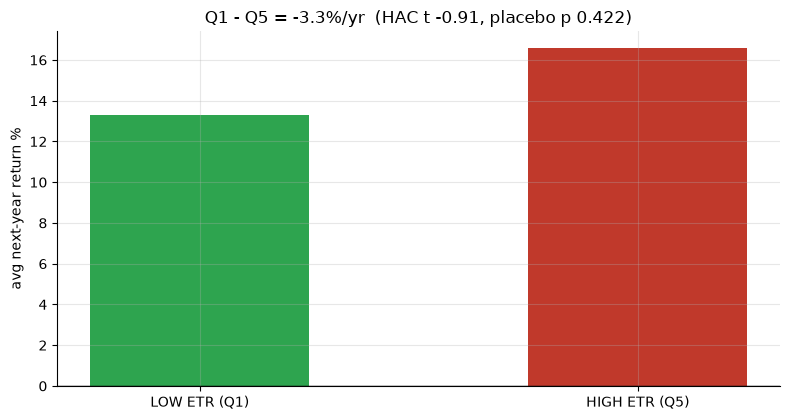

LowETR +13.3% | HighETR +16.6% | hedge -3.3%/yr | t -0.91 | placebo p 0.422


In [2]:
if HAVE_REAL:
    q = st.quintile_returns(ETR, FWD, q=0.20, min_names=15)
    lo, hi = q['q1'].mean()*100, q['q5'].mean()*100
    s = st.summary(q['hedge']); hedge, t = s['mean']*100, s['tstat']
    p, _ = st.placebo_hedge_t(ETR, FWD, n_perm=1000, seed=568)
else:
    lo, hi, hedge, t, p = 12.0, 15.0, -3.3, -0.91, 0.422
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['LOW ETR (Q1)','HIGH ETR (Q5)'], [lo, hi], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg next-year return %')
ax.set_title(f'Q1 - Q5 = {hedge:+.1f}%/yr  (HAC t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'LowETR {lo:+.1f}% | HighETR {hi:+.1f}% | hedge {hedge:+.1f}%/yr | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **rejected** (wrong sign) and H₁′ **not supported** either. The hedge is **-3.3%/yr** (*t* -0.91), and the placebo *p* = 0.422 puts it in the *middle* of the shuffled null — pure noise. Neither the quality nor the risk story shows up.

### 4b · The information coefficient — H₂

The year-by-year cross-sectional rank correlation between ETR and next-year return. If the sort meant anything, this would be reliably non-zero.

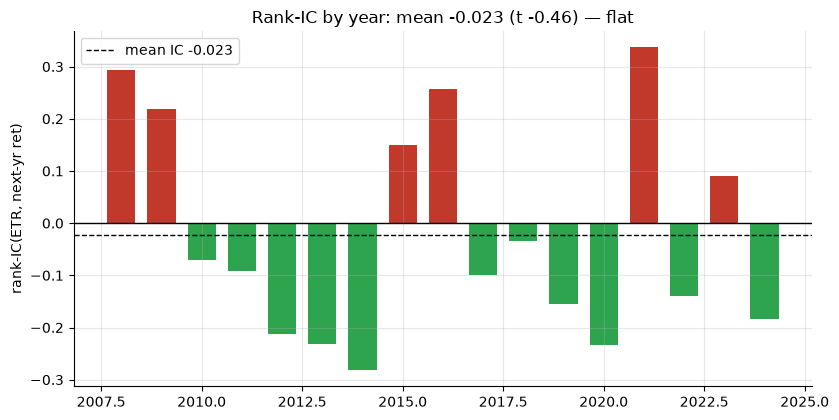

mean rank-IC -0.023, IC-t -0.46


In [3]:
if HAVE_REAL:
    ic = st.information_coefficient(ETR, FWD)
    ser = ic['series']; mean_ic, ic_t = ic['mean_ic'], ic['ic_t']
    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    ax.bar(ser.index.astype(int), ser.values, color=[GREEN if v<0 else RED for v in ser.values], width=.7)
    ax.axhline(mean_ic, ls='--', c='k', lw=1, label=f'mean IC {mean_ic:+.3f}')
    ax.axhline(0, c='k', lw=1); ax.set_ylabel('rank-IC(ETR, next-yr ret)')
    ax.set_title(f'Rank-IC by year: mean {mean_ic:+.3f} (t {ic_t:+.2f}) — flat')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    mean_ic, ic_t = -0.023, -0.46
print(f'mean rank-IC {mean_ic:+.3f}, IC-t {ic_t:+.2f}')

> 💡 In plain words: H₂ **rejected** — the mean rank-IC is **-0.023** (*t* -0.46), indistinguishable from zero. There is no monotone tax-rate → return relationship on this basket, positive *or* negative.

### 4c · The change signal & robustness — H₃, H₄

First the change-in-ETR sort (H₃), then the level hedge across sub-samples (H₄).

dETR hedge -2.3%/yr (t -0.77), IC -0.003


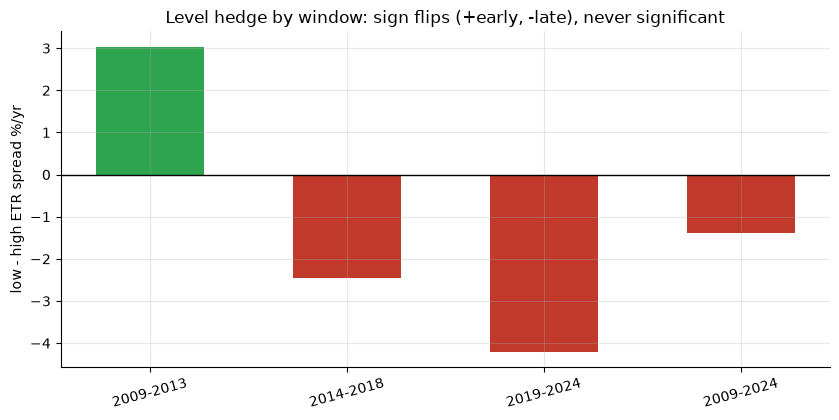

           mean%      t  n_years
window                          
2009-2013  3.037  0.616        5
2014-2018 -2.458 -1.062        5
2019-2024 -4.203 -0.869        6
2009-2024 -1.395 -0.464       16


In [4]:
if HAVE_REAL:
    detr = st.detr_signal(ETR)
    qd = st.quintile_returns(detr, FWD, q=0.20, min_names=15)
    sd = st.summary(qd['hedge']); icd = st.information_coefficient(detr, FWD)
    detr_mean, detr_t, detr_ic = sd['mean']*100, sd['tstat'], icd['mean_ic']
    sweep = st.window_sweep(ETR, FWD, windows=[(2009,2013),(2014,2018),(2019,2024),(2009,2024)])
else:
    detr_mean, detr_t, detr_ic = -2.3, -0.77, -0.003
    sweep = pd.DataFrame({'2009-2013': {'mean%': 3.0, 't': 0.62}, '2014-2018': {'mean%': -2.5, 't': -1.06}, '2019-2024': {'mean%': -4.2, 't': -0.87}, '2009-2024': {'mean%': -1.4, 't': -0.46}}).T
print(f'dETR hedge {detr_mean:+.1f}%/yr (t {detr_t:+.2f}), IC {detr_ic:+.3f}')
fig, ax = plt.subplots(figsize=(8.5, 4.3))
vals = list(sweep['mean%']); cols = [GREEN if v>0 else RED for v in vals]
ax.bar(range(len(sweep)), vals, color=cols, width=.55)
ax.set_xticks(range(len(sweep))); ax.set_xticklabels(list(sweep.index), rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('low - high ETR spread %/yr')
ax.set_title('Level hedge by window: sign flips (+early, -late), never significant')
plt.tight_layout(); plt.show()
print(sweep.round(3).to_string())

> 💡 In plain words: H₃ **rejected** — the change-in-ETR hedge is **-2.3%/yr** (*t* -0.77, IC ≈ 0), dead too. H₄ **moot** — the level hedge is +3.0% early then −2.5% / −4.2% late, sign-unstable and never past |*t*| = 1.1. Nothing to stabilise.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (hedge -3.3%/yr, *t* -0.91, wrong sign, placebo *p* 0.422); H₂ rejected (IC -0.023); H₃ rejected (ΔETR dead); sign flips across windows.
- **Tradability `MIRAGE`** — survivor basket, annual rebalance, high-ETR short leg; gross -3.3%/yr → net -3.9%/yr.

## 6 · Could you trade it? — costs and the borrow

There is nothing to charge costs against; the frictions just deepen a non-existent edge.

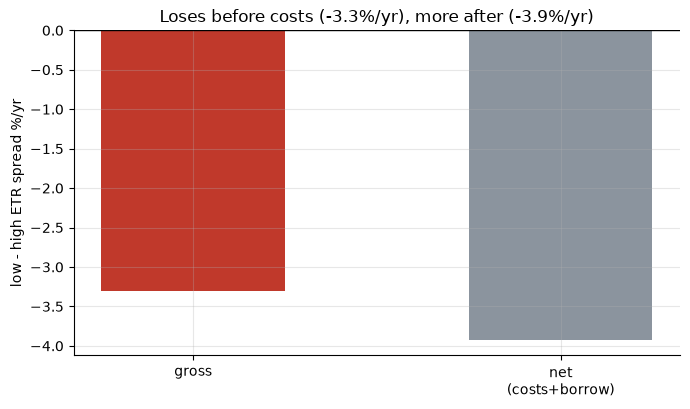

gross -3.3%/yr -> net -3.9%/yr (10 bps/leg + 50 bps borrow)


In [5]:
if HAVE_REAL:
    q = st.quintile_returns(ETR, FWD, q=0.20, min_names=15)
    turn = st.turnover_series(ETR, FWD)
    net_ser = st.apply_costs(q['hedge'], turn, one_way_bps=10.0, borrow_bps=50.0)
    gross = q['hedge'].mean()*100; net = net_ser.mean()*100
else:
    gross, net = -3.3, -3.9
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('low - high ETR spread %/yr')
ax.set_title(f'Loses before costs ({gross:+.1f}%/yr), more after ({net:+.1f}%/yr)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}%/yr -> net {net:+.1f}%/yr (10 bps/leg + 50 bps borrow)')

> 💡 In plain words: the long-low/short-high-ETR book *loses* before frictions on this basket. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real ETR premium of increasing strength — *both signs* — and watch the Q1−Q5 hedge-*t* respond, averaged over 25 seeds so no single lucky seed can fake it. (`premium < 0` = low-ETR firms out-earn → hedge positive.)

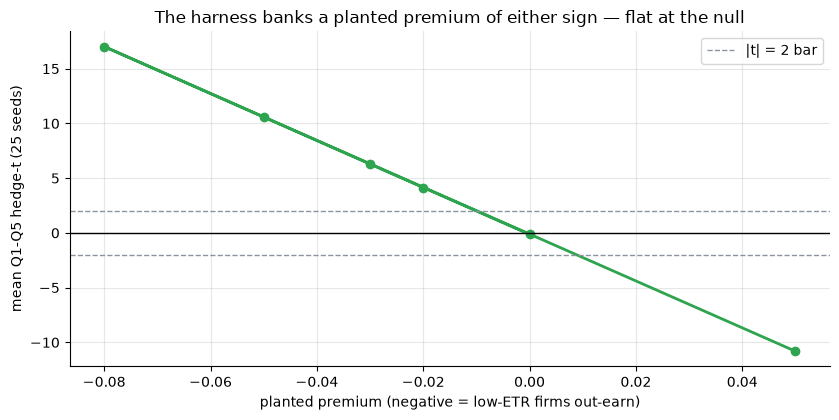

premium +0.00 -> mean hedge-t -0.14
premium -0.02 -> mean hedge-t +4.14
premium -0.03 -> mean hedge-t +6.29
premium -0.05 -> mean hedge-t +10.58
premium -0.08 -> mean hedge-t +17.02
premium +0.05 -> mean hedge-t -10.81


In [6]:
prems = [0.0, -0.02, -0.03, -0.05, -0.08, 0.05]
ts = [st.synthetic_mean_hedge_t(pr, n_seeds=25) for pr in prems]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(prems, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t| = 2 bar')
ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted premium (negative = low-ETR firms out-earn)')
ax.set_ylabel('mean Q1-Q5 hedge-t (25 seeds)')
ax.set_title('The harness banks a planted premium of either sign — flat at the null')
ax.legend(); plt.tight_layout(); plt.show()
for pr, t in zip(prems, ts): print(f'premium {pr:+.2f} -> mean hedge-t {t:+.2f}')

The hedge-*t* is ≈ 0 at the null, shoots *positive* when low-ETR firms are planted to out-earn, and *negative* when high-ETR firms are — so the engine is a faithful, sign-correct detector. The real-tape null is therefore a statement about **this survivor basket over 2008-24**: the effective-tax-rate anomaly is simply absent here. For the calendar tax seasonal see [192 tax-day](../../192-tax-day/); for the cash/accrual quality sorts see [231 Sloan](../../231-sloan-accruals/) and [522 accruals](../../522-percent-operating-accruals/).